                   CARROT-CHASING PERFORMANCE METRICS WITH STEADY-STATE & SETTLING TIME ANALYSIS                   

--- [A] STRAIGHT LINE PATH PERFORMANCE ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
-------------------------------------------------------------------------------------------------------------------
Delta (δ)=0   |   22.272m |   70.711m |   25.967m |    18.566m | DNC               | DNC              
Delta (δ)=10  |    7.791m |   70.711m |   16.721m |     0.034m | 14.05 s           | 18.20 s          
Delta (δ)=30  |    7.232m |   70.711m |   16.944m |     0.000m | 11.40 s           | 12.75 s          
Delta (δ)=50  |    7.731m |   70.711m |   17.716m |     0.024m | 11.20 s           | 15.40 s          

--- [B] LOITER CIRCULAR PATH PERFORMANCE ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
------------------------------------------------------

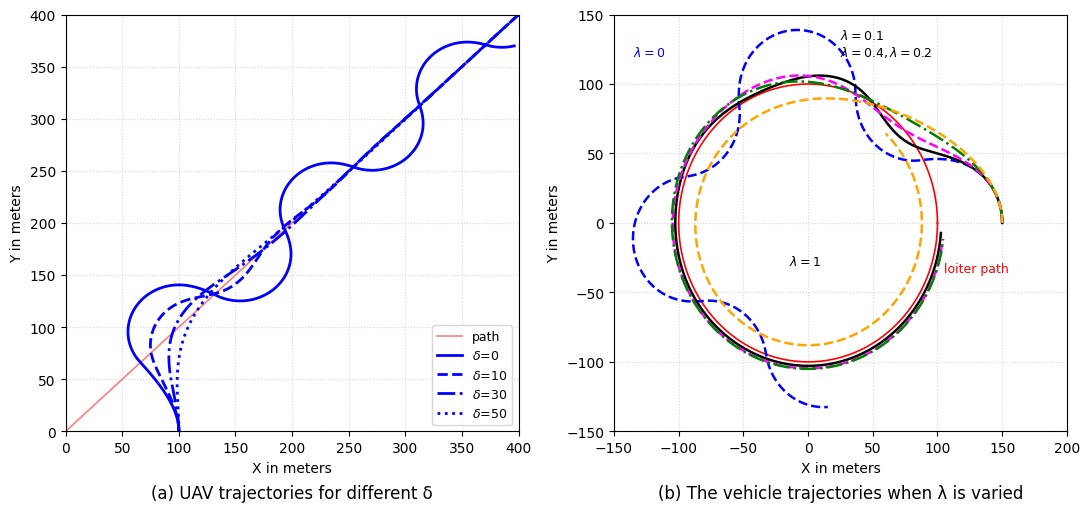

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- System & Environmental Constraints from the PDF Paper ---
V_A = 15.0             # Airspeed = 15 m/s
R_MIN = 45.0           # Minimum turning radius = 45 m
W_MAX = V_A / R_MIN    # Bounded maximum turn rate: 0.3333 rad/s
DT = 0.05              # Simulation integration step

def update_uav_kinematics(p, psi, u, dt=DT):
    """2D Dubins car unicycle kinematics with strict rate saturation bounds."""
    u_sat = np.clip(u, -W_MAX, W_MAX)

    x, y = p
    x_next = x + V_A * np.cos(psi) * dt
    y_next = y + V_A * np.sin(psi) * dt
    psi_next = psi + u_sat * dt

    # Wrap heading angle within [-pi, pi]
    psi_next = (psi_next + np.pi) % (2 * np.pi) - np.pi
    return np.array([x_next, y_next]), psi_next

# --- Algorithm 1: Straight Line Following ---
def simulate_straight_line(delta, t_max=45):
    Wi = np.array([0.0, 0.0])
    Wi1 = np.array([400.0, 400.0])

    # Paper initial conditions: Position (100, 0), Heading 90 degrees (facing North)
    p = np.array([100.0, 0.0])
    psi = np.pi / 2
    kappa = 0.45     # Gain parameter

    trajectory = [p.copy()]
    steps = int(t_max / DT)

    for _ in range(steps):
        Ru = np.linalg.norm(Wi - p)
        theta = np.arctan2(Wi1[1] - Wi[1], Wi1[0] - Wi[0])
        theta_u = np.arctan2(p[1] - Wi[1], p[0] - Wi[0])
        beta = theta - theta_u

        # Compute along-track projection distance
        R = np.sqrt(np.maximum(0, Ru**2 - (Ru * np.sin(beta))**2))
        if np.cos(beta) < 0:
            R = -R

        # Virtual Target Point (Carrot position)
        xt_prime = (R + delta) * np.cos(theta) + Wi[0]
        yt_prime = (R + delta) * np.sin(theta) + Wi[1]

        # Desired Heading & Proportional Control Command
        psi_d = np.arctan2(yt_prime - p[1], xt_prime - p[0])
        error = np.arctan2(np.sin(psi_d - psi), np.cos(psi_d - psi))
        u = kappa * error

        p, psi = update_uav_kinematics(p, psi, u)
        trajectory.append(p.copy())

        if p[0] > 410 or p[1] > 410:
            break

    return np.array(trajectory)

# --- Algorithm 2: Loiter Following ---
def simulate_loiter(lambda_val, t_max=45):
    O = np.array([0.0, 0.0])
    r = 100.0

    # Paper initial conditions: Position (150, 0), Heading 90 degrees (facing North)
    p = np.array([150.0, 0.0])
    psi = np.pi / 2
    kappa = 0.45

    trajectory = [p.copy()]
    steps = int(t_max / DT)

    for _ in range(steps):
        theta = np.arctan2(p[1] - O[1], p[0] - O[0])

        # Virtual target on circular track circumference
        xt_prime = r * np.cos(theta + lambda_val) + O[0]
        yt_prime = r * np.sin(theta + lambda_val) + O[1]

        # Desired Heading & Control Command
        psi_d = np.arctan2(yt_prime - p[1], xt_prime - p[0])
        error = np.arctan2(np.sin(psi_d - psi), np.cos(psi_d - psi))
        u = kappa * error

        p, psi = update_uav_kinematics(p, psi, u)
        trajectory.append(p.copy())

    return np.array(trajectory)

# --- Helper function for Settling Time ---
def calculate_settling_time(xte_array, threshold, dt=DT):
    """Finds the time when XTE drops below a threshold and stays there."""
    above_threshold_indices = np.where(xte_array >= threshold)[0]
    if len(above_threshold_indices) == 0:
        return 0.0  # Already below threshold from step 0

    last_above_index = above_threshold_indices[-1]
    # If the last element of the simulation is still above the threshold, it never settled
    if last_above_index == len(xte_array) - 1:
        return None

    return (last_above_index + 1) * dt

# --- Error Calculation Metrics ---
def compute_straight_line_errors(trajectory):
    """Calculates comprehensive spatial errors relative to the line from (0,0) to (400,400)"""
    x = trajectory[:, 0]
    y = trajectory[:, 1]

    # Cross-Track Error geometric derivation for a perfect 45-degree line diagonal
    xte = np.abs(x - y) / np.sqrt(2)

    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]

    t_settle_5m = calculate_settling_time(xte, threshold=5.0)
    t_settle_2m = calculate_settling_time(xte, threshold=2.0)

    return mean_xte, max_xte, rmse, final_xte, t_settle_5m, t_settle_2m

def compute_loiter_errors(trajectory):
    """Calculates comprehensive spatial errors relative to a circle centered at (0,0) with radius 100"""
    radial_distances = np.linalg.norm(trajectory, axis=1)
    xte = np.abs(radial_distances - 100.0)

    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]

    t_settle_5m = calculate_settling_time(xte, threshold=5.0)
    t_settle_2m = calculate_settling_time(xte, threshold=2.0)

    return mean_xte, max_xte, rmse, final_xte, t_settle_5m, t_settle_2m


# --- Execution, Analysis, and Plot Generation Engine ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.2))

print("=" * 115)
print(f"{'CARROT-CHASING PERFORMANCE METRICS WITH STEADY-STATE & SETTLING TIME ANALYSIS':^115}")
print("=" * 115)

# --- Process (a) Straight Line Figure 2(a) ---
ax1.plot([0, 400], [0, 400], color='#ff7f7f', linestyle='-', linewidth=1.2, label='path')

deltas = [0, 10, 30, 50]
styles = ['b-', 'b--', 'b-.', 'b:']
labels = ['$\\delta$=0', '$\\delta$=10', '$\\delta$=30', '$\\delta$=50']

print("\n--- [A] STRAIGHT LINE PATH PERFORMANCE ---")
header = f"{'Config':<12} | {'Mean XTE':<10} | {'Max XTE':<10} | {'RMSE':<10} | {'Final XTE':<11} | {'Settle Time (5m)':<17} | {'Settle Time (2m)':<17}"
print(header)
print("-" * 115)

for d, style, lbl in zip(deltas, styles, labels):
    traj = simulate_straight_line(delta=d)
    ax1.plot(traj[:, 0], traj[:, 1], style, label=lbl, linewidth=2)

    # Calculate performance metrics
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_straight_line_errors(traj)

    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"

    print(f"Delta (\u03b4)={d:<3} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

ax1.set_xlabel('X in meters', fontsize=10)
ax1.set_ylabel('Y in meters', fontsize=10)
ax1.set_xlim(0, 400)
ax1.set_ylim(0, 400)
ax1.set_xticks(np.arange(0, 450, 50))
ax1.set_yticks(np.arange(0, 450, 50))
ax1.legend(loc='lower right', frameon=True, fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.set_title('(a) UAV trajectories for different \u03b4', y=-0.18, fontsize=12)

# --- Process (b) Loiter Figure 2(b) ---
circle_pts = np.linspace(0, 2 * np.pi, 300)
ax2.plot(100 * np.cos(circle_pts), 100 * np.sin(circle_pts), 'r-', linewidth=1.2)

lambdas = [0, 0.1, 0.2, 0.4, 1.0]
colors = ['blue', 'black', 'magenta', 'green', 'orange']
line_styles = ['--', '-', '--', '-.', '--']

print("\n--- [B] LOITER CIRCULAR PATH PERFORMANCE ---")
print(header)
print("-" * 115)

for l, c, ls in zip(lambdas, colors, line_styles):
    traj = simulate_loiter(lambda_val=l)
    ax2.plot(traj[:, 0], traj[:, 1], color=c, linestyle=ls, linewidth=1.8)

    # Calculate performance metrics
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_loiter_errors(traj)

    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"

    print(f"Lambda (\u03bb)={l:<2} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

# Positional text labels layout matching the paper's style
ax2.text(-135, 120, '$\\lambda=0$', color='blue', fontsize=9)
ax2.text(25, 120, '$\\lambda=0.1$\n$\\lambda=0.4, \\lambda=0.2$', color='black', fontsize=9)
ax2.text(-15, -30, '$\\lambda=1$', color='black', fontsize=9)
ax2.text(105, -35, 'loiter path', color='red', fontsize=9)

ax2.set_xlabel('X in meters', fontsize=10)
ax2.set_ylabel('Y in meters', fontsize=10)
ax2.set_xlim(-150, 200)
ax2.set_ylim(-150, 150)
ax2.set_xticks(np.arange(-150, 250, 50))
ax2.set_yticks(np.arange(-150, 200, 50))
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.set_title('(b) The vehicle trajectories when \u03bb is varied', y=-0.18, fontsize=12)

print("\n" + "=" * 115)
plt.tight_layout()
plt.show()